# Project 1

In [5]:
import numpy as np
import matplotlib.pyplot as plt

## Task 1

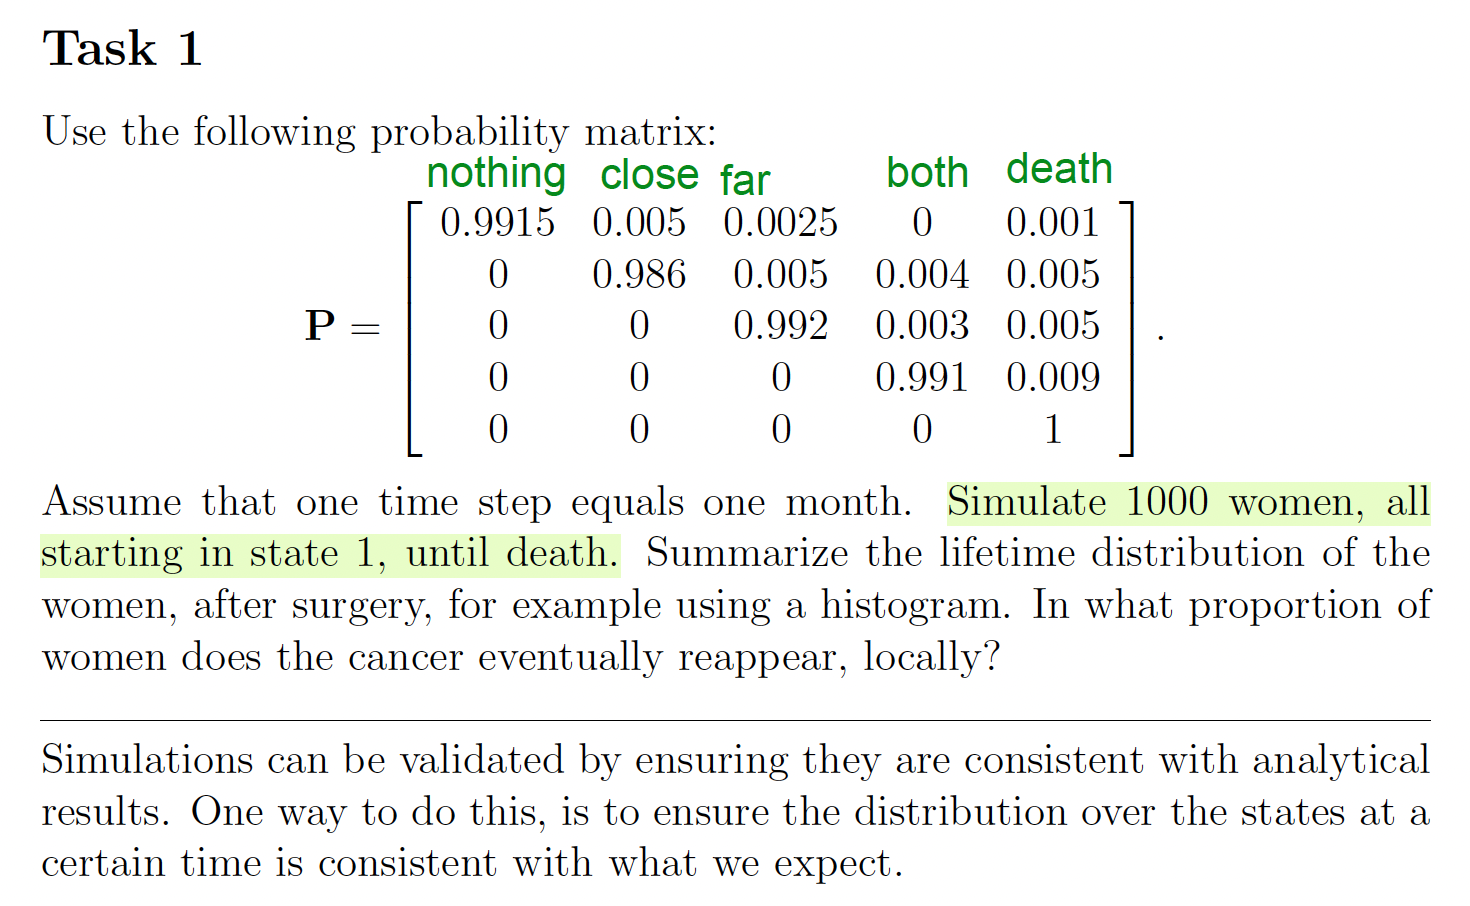

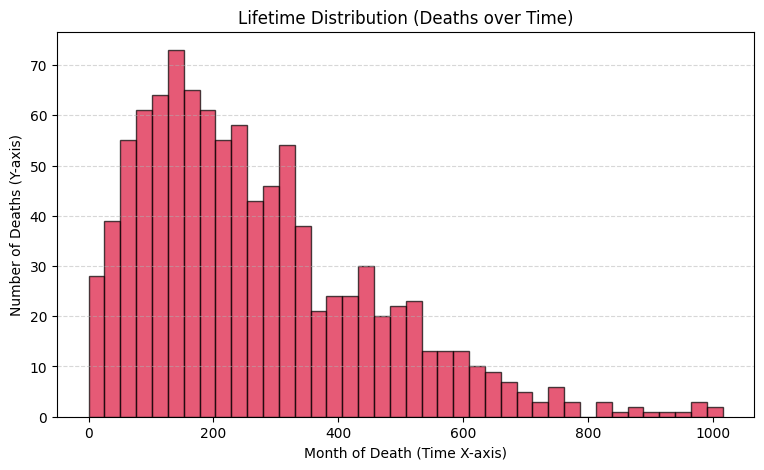

In [ ]:
sim_num = 1000
months = 1000000

P = np.array([[0.9915,0.005, 0.0025, 0, 0.001],
              [0, 0.986, 0.005, 0.004, 0.005],
              [0,0,0.992,0.003,0.005],
              [0,0,0,0.991,0.009],
              [0,0,0,0,1]])

def Task1_sim(sim_num, months, P):
    states = np.array([0,1,2,3,4])
    #Alle 1000 women start in state 0
    women_states_index = np.zeros(sim_num, dtype=int)

    # Track if a specific woman has ever had local cancer
    has_local_cancer = np.zeros(sim_num, dtype=bool)

    death_months = np.zeros(sim_num, dtype=int)

    current_state = np.array([sim_num,0,0,0,0])

    pt_list = []
    for t in range(months):
        for woman in range(sim_num):
            current_state = women_states_index[woman]
            #if she is dead we skipp her
            if current_state == 4:
                continue
            choice = np.random.choice(states, p=P[current_state])
            women_states_index[woman] = choice
            #if she gets stage 1 we make it true that she has local cancer.
            if choice == 1:
                has_local_cancer[woman] = True

            #If she is dies now this is her death month
            if choice == 4:
                death_months[woman] = t 

        counts = np.bincount(women_states_index, minlength=5)
        pt_list.append(counts)
        #We break before time if weveryone is dead
        if np.all(counts == np.array([0, 0, 0, 0, sim_num])):
            break
    
    women_getting_local_cancer=np.sum(has_local_cancer)

    return pt_list, women_getting_local_cancer, death_months


# Run simulation
pt_list, local_cancer, death_months = Task1_sim(sim_num, months, P)

# --- PLOT THE HISTOGRAM ---
plt.figure(figsize=(9, 5))
# death_months tells us exactly when each of the 1000 women died
plt.hist(death_months, bins=40, color='crimson', edgecolor='black', alpha=0.7)

plt.title("Lifetime Distribution (Deaths over Time)")
plt.xlabel("Month of Death (Time X-axis)")
plt.ylabel("Number of Deaths (Y-axis)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## Task 2

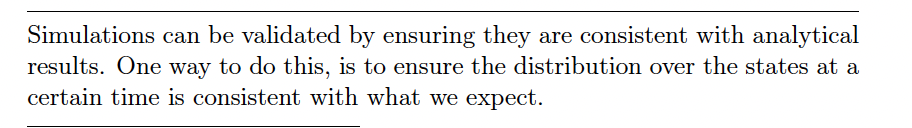
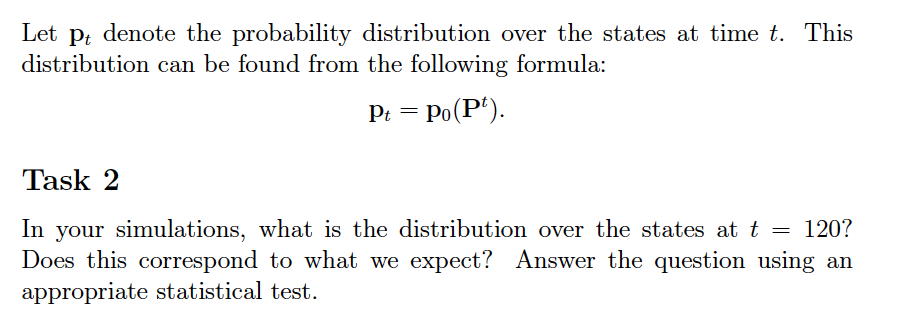


In [12]:
#--------Theoretical
np.random.seed(42)
P = np.array([
    [0.9915, 0.0050, 0.0025, 0.0000, 0.0010],
    [0.0000, 0.9860, 0.0050, 0.0040, 0.0050],
    [0.0000, 0.0000, 0.9920, 0.0030, 0.0050],
    [0.0000, 0.0000, 0.0000, 0.9910, 0.0090],
    [0.0000, 0.0000, 0.0000, 0.0000, 1.0000]
])
p0 = np.array([1000,0,0,0,0])

months = 120

def sim_woman_lifetimes(P, months, p0):
    death_rate_at_t = []
    T = []
    p_list = [p0]
    p=p0
    for t in range(months):
        p = p @ P
        death_rate_at_t.append(p[-1])
        T.append(t)
        p_list.append(p)
        if p[-1]>=999.5:
            break
    return death_rate_at_t, p_list, T

death_rate_at_t, p_list, T = sim_woman_lifetimes(P, months, p0)
p_list[-1]
    

array([359.02626821, 158.95603979, 166.08689731,  67.74149395,
       248.18930075])

In [13]:
np.random.seed(42)
pt_list, local_cancer, death_months = Task1_sim(sim_num, 120, P)

pt_list[-1]

array([370, 148, 177,  73, 232])

In [17]:
import numpy as np
from scipy.stats import chisquare

observed = pt_list[-1] 

expected = p_list[-1] 

chi2_stat, p_value = chisquare(f_obs=observed, f_exp=expected)

print(f"Chi-square Statistic: {chi2_stat:.4f}")
print(f"p-value: {p_value:.4f}")

Chi-square Statistic: 3.2718
p-value: 0.5134


## Task 3

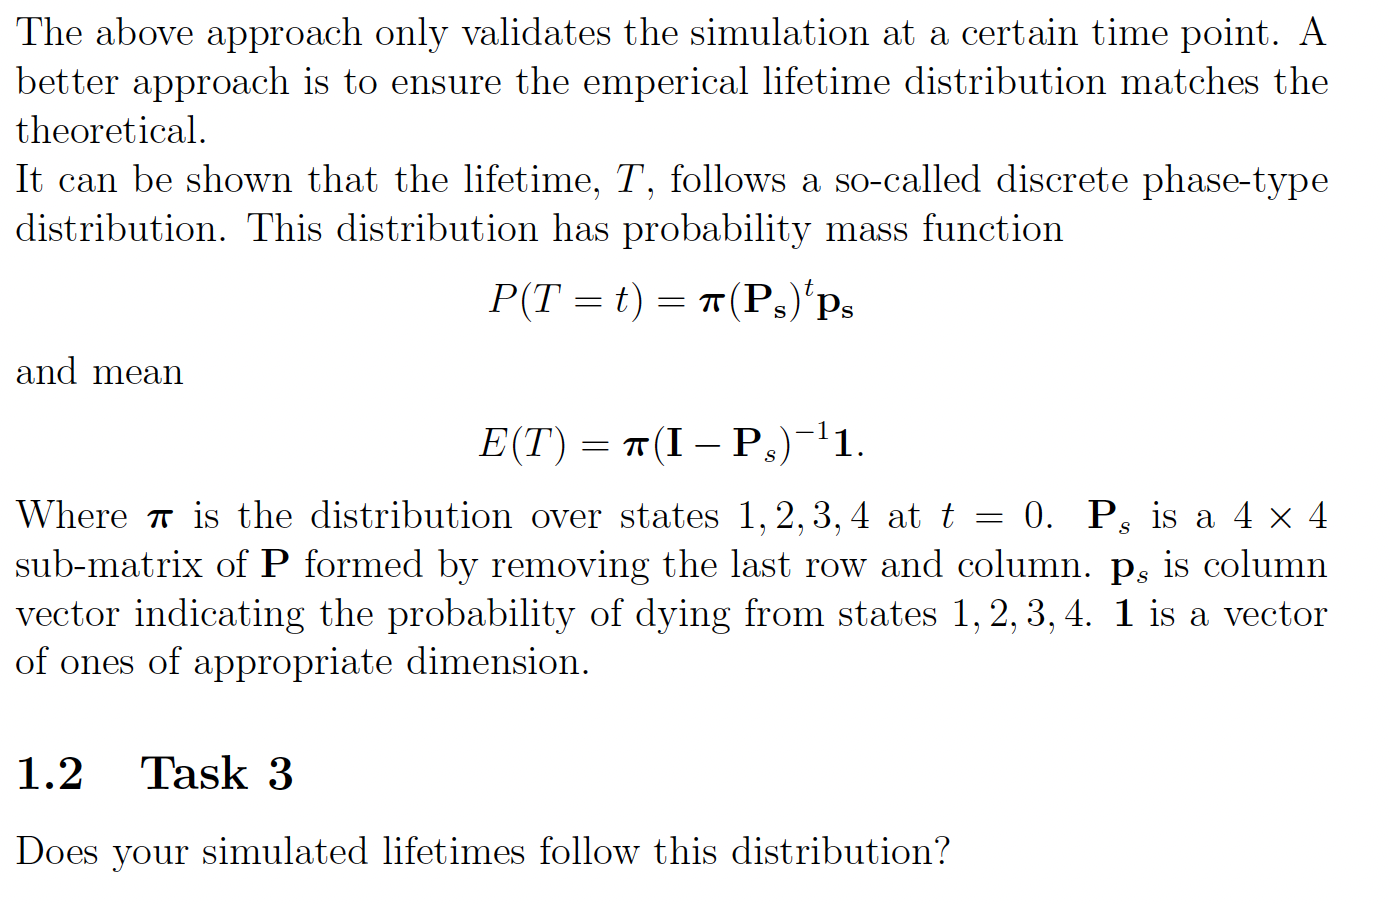

[1.         1.029      1.057676   ... 0.00736905 0.00731733 0.00726596]


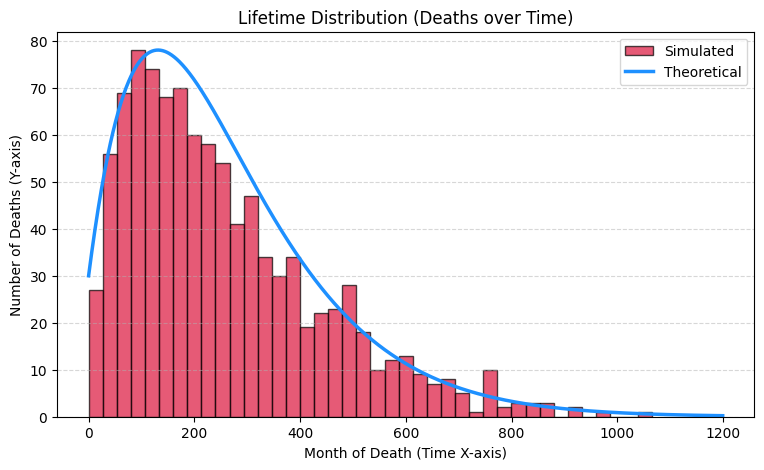

In [31]:
sim_num = 1000
months = 1200

Pi= np.array([sim_num, 0,0,0])
Ps = np.array([
    [0.9915, 0.0050, 0.0025, 0.0000],
    [0.0000, 0.9860, 0.0050, 0.0040],
    [0.0000, 0.0000, 0.9920, 0.0030],
    [0.0000, 0.0000, 0.0000, 0.9910]
])
ps= np.array([0.0010, 0.0050, 0.0050, 0.0090])

#Theoretical lifetime distribution
def prop_mass_T(t, Pi, Ps, ps):
    Ps_t = np.linalg.matrix_power(Ps, t)
    return Pi@ Ps_t @ps

def mean_T(t, Pi, Ps):
    return Pi@np.linalg.inv(np.eye(4)-Ps )@np.ones(4)

theo_mass = []
for t in range(months):
    theo_mass.append(prop_mass_T(t, Pi, Ps, ps))

theo_mass = np.array(theo_mass)

print(theo_mass)

pt_list, local_cancer, death_months = Task1_sim(sim_num, months, P)

# --- PLOT THE HISTOGRAM & THEORETICAL LINE ---
plt.figure(figsize=(9, 5))
plt.hist(death_months, bins=40, color='crimson', edgecolor='black', alpha=0.7, label='Simulated')

bin_width = 1200 / 40  
plt.plot(range(1200), theo_mass * bin_width, color='dodgerblue', linewidth=2.5, label='Theoretical')

plt.title("Lifetime Distribution (Deaths over Time)")
plt.xlabel("Month of Death (Time X-axis)")
plt.ylabel("Number of Deaths (Y-axis)")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


## Task 4

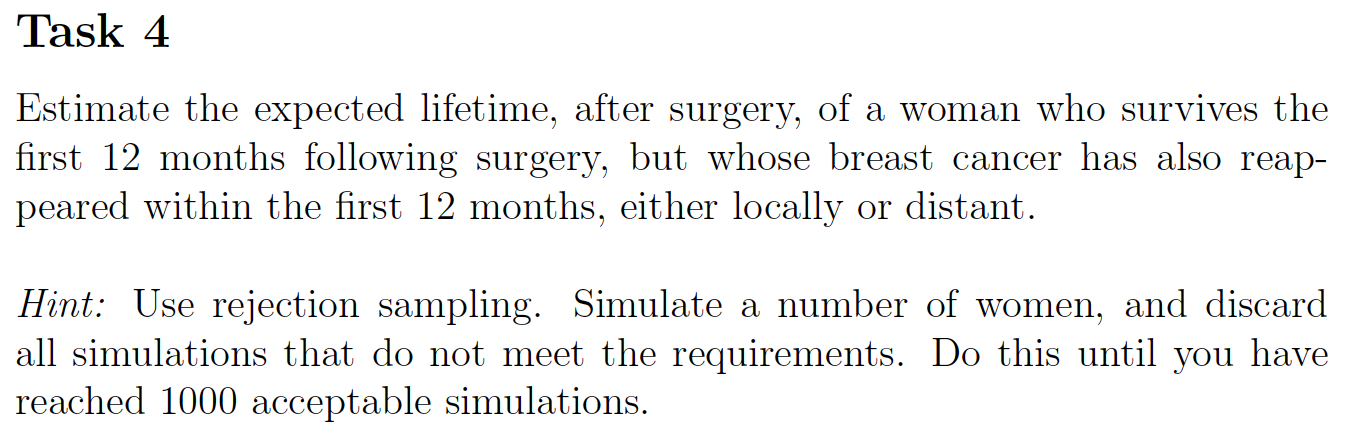

In [40]:
# we have this code for simulating one woman
def simulate_a_woman(X0,P):
    #X0 is initial state
    # P is probability matrix 
    states = np.array([0,1,2,3,4])
    States = []
    current_state =X0

    while current_state !=4:
        current_state = np.random.choice(states, p=P[current_state])
        States.append(current_state)

    #returns the list of all the states a woman is in in her lifetime, lenght of that is amount of months she lives 
    return np.array(States)

#Rejection sampling 
def rejection_sampling_women(simulate_a_woman, P):
    Women = []
    np.random.seed(42)
    while len(Women)!=1000:
        #we simulate a woman
        X = simulate_a_woman(0,P)
        #if she has had local cancer in the first 12 months AND lives past 12 months we accept
        if (1 in X[:12]) and (len(X)>12):
            Women.append(X) 
        #if she has had distant cancer in the first 12 months AND lives past 12 months we accept
        elif (2 in X[:12]) and (len(X)>12):
            Women.append(X)
        #otherwise we reject. 
    return Women

Women = rejection_sampling_women(simulate_a_woman, P)

In [ ]:
length = []
for woman in Women:
    length.append(len(woman))
mean_life = np.mean(length)
#Expected lifetime
mean_life

np.float64(178.715)

## Task 5

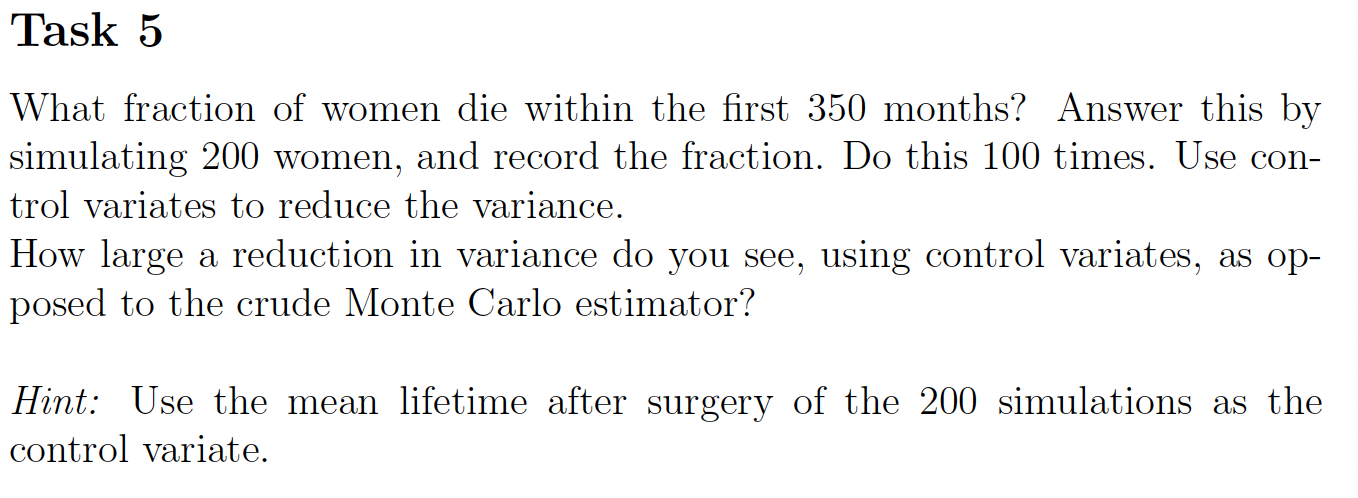

In [46]:
np.random.seed(42)
simulated_women = 200
simulation_times = 100

def crude_montecarlo(simulated_women, simulation_times):
    fractions = []
    for t in range(simulation_times):
        frac = 0
        for i in range(simulated_women):
            woman = simulate_a_woman(0,P)
            if  len(woman) < 350:
                frac += 1
        fraction = frac / simulated_women
        fractions.append(fraction)
    return np.mean(fractions)
    

fractions = crude_montecarlo(simulated_women, simulation_times)
fractions


np.float64(0.73645)